# Electricity Load Forecasting with Temporal Convolutional Networks (TCN)

This notebook details a comprehensive workflow for forecasting electricity load using a Temporal Convolutional Network (TCN) model. The process involves data loading, exploratory data analysis, cross-validation setup, data preparation, TCN model definition and training with hyperparameter tuning, model evaluation, and interpretability analysis using SHAP.

## 1. Data Loading and Initial Exploration
- **Data Source:** Electricity load data is loaded from a CSV file hosted on GitHub.
- **Initial Checks:** The dataset's shape, datetime range (`2015-01-03 01:00:00` to `2020-06-27 00:00:00`), and head are displayed.
- **Libraries:** Pandas and NumPy are used for data manipulation.

## 2. Time Series Visualization and Feature Engineering
- **Datetime Conversion:** The 'datetime' column is converted to datetime objects and sorted.
- **Feature Extraction:** 'year', 'month', and 'date' columns are extracted from 'datetime'.
- **Load Statistics:** Basic statistics (mean, std dev, min, max) for 'nat_demand' (national demand) are printed.
- **Comprehensive Visualization:** Several plots are generated using `matplotlib` to understand:
    - The full electricity load time series from 2015-2020.
    - Yearly load patterns, showing trends and hourly data points for each year.
    - Monthly average load patterns, highlighting seasonal variations with error bars for standard deviation.
    - Daily average load profiles, revealing hourly consumption cycles.
- **Observations:** Peak demand months and hours are identified and printed for each year.

## 3. Cross-Validation Split Setup (Expanding Window)
- **Strategy:** A 5-fold expanding window cross-validation approach is implemented to simulate real-world forecasting scenarios where models are trained on progressively larger historical datasets.
- **Folds Defined:**
    - CV1: Train on 2015, Validate on 2016
    - CV2: Train on 2015-2016, Validate on 2017
    - CV3: Train on 2015-2017, Validate on 2018
    - CV4: Train on 2015-2018, Validate on 2019
    - CV5: Train on 2015-2019, Validate on Jan-Feb 2020
- **Target & Features:** 'nat_demand' is set as the target, and other relevant columns (excluding 'datetime', 'year', 'month', 'date') are considered as features.

## 4. Data Preparation for TCN Training
- **Sequence Creation:** A `create_sequences` function is defined to transform the time series data into sequences suitable for TCNs.
    - `lookback = 24`: The model looks back 24 hours to predict future demand.
    - `horizons = [12, 24]`: Predictions are made for 12 and 24 hours ahead.
- **Feature Selection:** Only numeric features are used (`feature_cols_numeric`).
- **Scaling:** `StandardScaler` from `sklearn.preprocessing` is applied to both features (X) and targets (y) for each train/validation split to ensure numerical stability and optimal model performance. Scalers are fitted on training data and used to transform validation data.

## 5. TCN Model Architecture (PyTorch)
- **TCNBlock:** A custom PyTorch `TCNBlock` is implemented, incorporating:
    - `nn.Conv1d` for temporal convolutions with dilation to capture long-range dependencies.
    - `nn.BatchNorm1d` for normalization.
    - `nn.Dropout` for regularization.
    - Residual connections to facilitate training of deeper networks.
- **TCNModel:** The main `TCNModel` assembles multiple `TCNBlock` layers with increasing dilation rates. It uses `nn.AdaptiveAvgPool1d` to aggregate temporal information before passing it to a final `nn.Linear` layer for the regression output.
- **Training Function:** A `train_model` function handles the training loop, including:
    - `nn.MSELoss` as the criterion.
    - `optim.Adam` as the optimizer.
    - Early stopping with a specified `patience` to prevent overfitting.
- **Device:** The model training leverages CUDA if available, otherwise defaults to CPU.

## 6. Hyperparameter Tuning
- **Methodology:** Randomized Search is performed on a subset of the data (CV1 fold for the 12-hour horizon) to efficiently find optimal hyperparameters.
- **Search Space:** Distributions for `num_channels`, `kernel_size`, `dropout`, `learning_rate`, and `batch_size` are defined.
- **Best Hyperparameters:** After `10` random iterations, the best combination found was:
    - `num_channels`: `[128, 128, 128]`
    - `kernel_size`: `3`
    - `dropout`: `0.1`
    - `learning_rate`: `0.0005`
    - `batch_size`: `64`
- **Result:** This combination yielded a validation RMSE of `113.83 MW` on the tuning fold.

## 7. Main Cross-Validation Training and Evaluation
- **Full Training:** The TCN model is trained across all 5 cross-validation folds for both 12-hour and 24-hour horizons, using the best hyperparameters identified during tuning.
- **Evaluation Metrics:** For each fold and horizon, the following metrics are calculated:
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - Mean Absolute Error (MAE)
    - Mean Absolute Percentage Error (MAPE)
- **Results Summary:** The metrics are displayed in a DataFrame, and average metrics across all folds are calculated for each horizon to provide an overall performance assessment.

## 8. Visualization of Predictions
- **Actual vs. Predicted Plots:** For each cross-validation fold and horizon, plots are generated to visualize the model's predicted load against the actual national demand values, offering a qualitative assessment of performance.

## 9. SHAP Analysis for Model Interpretability
- **Purpose:** SHAP (SHapley Additive exPlanations) is used to interpret the TCN model's predictions by explaining the contribution of each feature to a specific prediction.
- **Selected Model:** The model trained for the 12-hour horizon, CV1 fold is chosen for detailed analysis.
- **DeepExplainer:** SHAP's `DeepExplainer` is used, suitable for deep learning models, with a random subset of training data as the background.
- **Visualization:**
    - **Summary Plot:** Displays the overall impact of features on the model output.
    - **Waterfall Plot:** Illustrates the contribution of each feature for a single prediction, showing how features push the prediction from the base value to the model's output.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/devipramita/Electricity-Load-Forecasting/master/continuous%20dataset.csv")
print(df.shape)
print(df.datetime.min(), df.datetime.max())
df.head()

(48048, 17)
2015-01-03 01:00:00 2020-06-27 00:00:00


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


TIME SERIES VISUALIZATION - Electricity Load 2015-2020

Data Range: 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Total records: 48,048
Frequency: Hourly data
Load statistics (MW):
  • Mean: 1182.87
  • Std Dev: 192.07
  • Min: 85.19
  • Max: 1754.88

✓ Saved visualization: 'load_timeseries_2015-2020.png'


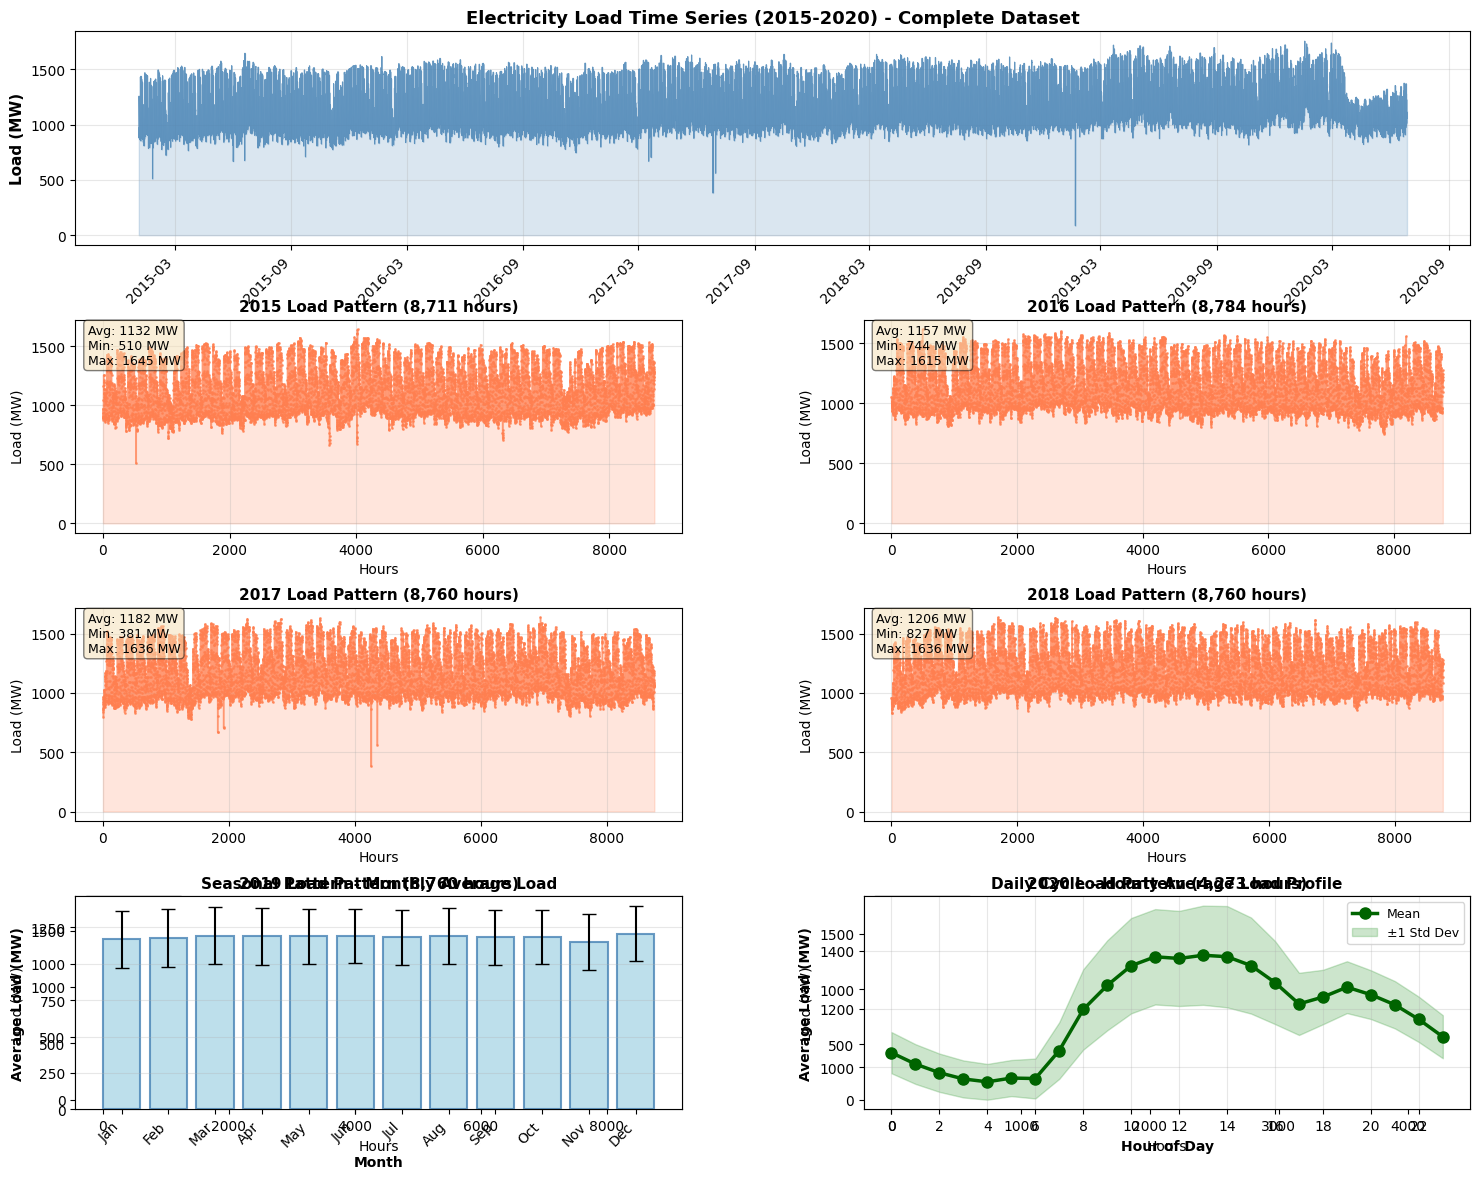


OBSERVATIONS FROM TIME SERIES:

2015:
  • Peak demand month: Dec (avg 1195 MW)
  • Peak demand hour: 13:00 (avg 1345 MW)

2016:
  • Peak demand month: Apr (avg 1218 MW)
  • Peak demand hour: 13:00 (avg 1368 MW)

2017:
  • Peak demand month: Apr (avg 1214 MW)
  • Peak demand hour: 13:00 (avg 1389 MW)

2018:
  • Peak demand month: Apr (avg 1229 MW)
  • Peak demand hour: 13:00 (avg 1415 MW)

2019:
  • Peak demand month: Dec (avg 1292 MW)
  • Peak demand hour: 13:00 (avg 1448 MW)

2020:
  • Peak demand month: Jan (avg 1277 MW)
  • Peak demand hour: 14:00 (avg 1306 MW)



In [4]:
# ============ TIME SERIES VISUALIZATION OF ELECTRICITY LOAD (2015-2020) ============
import matplotlib.dates as mdates

print("="*80)
print("TIME SERIES VISUALIZATION - Electricity Load 2015-2020")
print("="*80 + "\n")

# Convert datetime to proper format
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Extract date info
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['date'] = df['datetime'].dt.date

load_col = 'nat_demand'  # Load column name

print(f"Data Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total records: {len(df):,}")
print(f"Frequency: Hourly data")
print(f"Load statistics (MW):")
print(f"  • Mean: {df[load_col].mean():.2f}")
print(f"  • Std Dev: {df[load_col].std():.2f}")
print(f"  • Min: {df[load_col].min():.2f}")
print(f"  • Max: {df[load_col].max():.2f}\n")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# 1. Full Time Series (2015-2020)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['datetime'], df[load_col], linewidth=0.8, color='steelblue', alpha=0.8)
ax1.fill_between(df['datetime'], df[load_col], alpha=0.2, color='steelblue')
ax1.set_ylabel('Load (MW)', fontsize=11, fontweight='bold')
ax1.set_title('Electricity Load Time Series (2015-2020) - Complete Dataset', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2-5. Yearly trends
years = sorted(df['year'].unique())
months_name = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for idx, year in enumerate(years):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2])

    year_data = df[df['year'] == year].reset_index(drop=True)
    ax.plot(range(len(year_data)), year_data[load_col], linewidth=1, color='coral', marker='o', markersize=1, alpha=0.7)
    ax.fill_between(range(len(year_data)), year_data[load_col], alpha=0.2, color='coral')

    ax.set_title(f'{year} Load Pattern ({len(year_data):,} hours)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Load (MW)', fontsize=10)
    ax.set_xlabel('Hours', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Add stats
    stats_text = f"Avg: {year_data[load_col].mean():.0f} MW\nMin: {year_data[load_col].min():.0f} MW\nMax: {year_data[load_col].max():.0f} MW"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 6. Monthly average patterns
ax6 = fig.add_subplot(gs[3, 0])
monthly_avg = df.groupby('month')[load_col].agg(['mean', 'std'])
ax6.bar(monthly_avg.index, monthly_avg['mean'], yerr=monthly_avg['std'],
        color='lightblue', edgecolor='steelblue', linewidth=1.5, capsize=5, alpha=0.8)
ax6.set_ylabel('Average Load (MW)', fontsize=10, fontweight='bold')
ax6.set_xlabel('Month', fontsize=10, fontweight='bold')
ax6.set_title('Seasonal Pattern - Monthly Average Load', fontsize=11, fontweight='bold')
ax6.set_xticks(range(1, 13))
ax6.set_xticklabels(months_name, rotation=45, ha='right')
ax6.grid(axis='y', alpha=0.3)

# 7. Hourly average patterns (daily cycle)
ax7 = fig.add_subplot(gs[3, 1])
hourly_avg = df.groupby(df['datetime'].dt.hour)[load_col].agg(['mean', 'std'])
ax7.plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2.5, markersize=8,
         color='darkgreen', label='Mean')
ax7.fill_between(hourly_avg.index,
                 hourly_avg['mean'] - hourly_avg['std'],
                 hourly_avg['mean'] + hourly_avg['std'],
                 alpha=0.2, color='green', label='±1 Std Dev')
ax7.set_ylabel('Average Load (MW)', fontsize=10, fontweight='bold')
ax7.set_xlabel('Hour of Day', fontsize=10, fontweight='bold')
ax7.set_title('Daily Cycle - Hourly Average Load Profile', fontsize=11, fontweight='bold')
ax7.set_xticks(range(0, 24, 2))
ax7.grid(True, alpha=0.3)
ax7.legend(loc='best', fontsize=9)

plt.savefig('load_timeseries_2015-2020.png', dpi=150, bbox_inches='tight')
print("✓ Saved visualization: 'load_timeseries_2015-2020.png'")

plt.show()

print("\n" + "="*80)
print("OBSERVATIONS FROM TIME SERIES:")
print("="*80)
for year in years:
    year_data = df[df['year'] == year]
    peak_month = year_data.groupby('month')[load_col].mean().idxmax()
    peak_day = year_data.groupby(year_data['datetime'].dt.hour)[load_col].mean().idxmax()
    print(f"\n{year}:")
    print(f"  • Peak demand month: {months_name[peak_month-1]} (avg {year_data[year_data['month']==peak_month][load_col].mean():.0f} MW)")
    print(f"  • Peak demand hour: {peak_day}:00 (avg {year_data[year_data['datetime'].dt.hour==peak_day][load_col].mean():.0f} MW)")
print("\n" + "="*80)

In [5]:
# ============ CV SPLIT SETUP - 5-FOLD EXPANDING WINDOW (2015-2020) ============

print("="*80)
print("CROSS-VALIDATION SPLIT SETUP")
print("="*80 + "\n")

# Ensure datetime is datetime format
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Add year and month columns
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

# Target and feature columns
target_col = 'nat_demand'  # Electricity load column
feature_cols = [col for col in df.columns if col not in ['datetime', 'year', 'month', target_col]]

print(f"Data overview:")
print(f"  • Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"  • Total samples: {len(df):,}")
print(f"  • Target column: {target_col}")
print(f"  • Feature columns ({len(feature_cols)}): {feature_cols}\n")

# Create 5-fold expanding window CV splits
cv_splits = {}

# CV1: train 2015 -> val 2016
cv_splits['cv1'] = {
    'train': df[df['year'] == 2015].copy(),
    'val': df[df['year'] == 2016].copy()
}

# CV2: train 2015-2016 -> val 2017
cv_splits['cv2'] = {
    'train': df[df['year'].isin([2015, 2016])].copy(),
    'val': df[df['year'] == 2017].copy()
}

# CV3: train 2015-2017 -> val 2018
cv_splits['cv3'] = {
    'train': df[df['year'].isin([2015, 2016, 2017])].copy(),
    'val': df[df['year'] == 2018].copy()
}

# CV4: train 2015-2018 -> val 2019
cv_splits['cv4'] = {
    'train': df[df['year'].isin([2015, 2016, 2017, 2018])].copy(),
    'val': df[df['year'] == 2019].copy()
}

# CV5: train 2015-2019 -> val 2020 (only months 01-02)
cv_splits['cv5'] = {
    'train': df[df['year'].isin([2015, 2016, 2017, 2018, 2019])].copy(),
    'val': df[(df['year'] == 2020) & (df['month'].isin([1, 2]))].copy()
}

print("Cross-Validation Fold Summary:")
print("-" * 80)
for fold_name, fold_data in cv_splits.items():
    train_data = fold_data['train']
    val_data = fold_data['val']
    print(f"\n{fold_name.upper()}:")
    print(f"  Train: {train_data['datetime'].min().strftime('%Y-%m-%d')} to {train_data['datetime'].max().strftime('%Y-%m-%d')} ({len(train_data):,} samples)")
    print(f"  Val:   {val_data['datetime'].min().strftime('%Y-%m-%d')} to {val_data['datetime'].max().strftime('%Y-%m-%d')} ({len(val_data):,} samples)")
    print(f"  Load range: {train_data[target_col].min():.0f} MW - {train_data[target_col].max():.0f} MW")

print("\n" + "="*80)

CROSS-VALIDATION SPLIT SETUP

Data overview:
  • Date range: 2015-01-03 01:00:00 to 2020-06-27 00:00:00
  • Total samples: 48,048
  • Target column: nat_demand
  • Feature columns (16): ['T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'date']

Cross-Validation Fold Summary:
--------------------------------------------------------------------------------

CV1:
  Train: 2015-01-03 to 2015-12-31 (8,711 samples)
  Val:   2016-01-01 to 2016-12-31 (8,784 samples)
  Load range: 510 MW - 1645 MW

CV2:
  Train: 2015-01-03 to 2016-12-31 (17,495 samples)
  Val:   2017-01-01 to 2017-12-31 (8,760 samples)
  Load range: 510 MW - 1645 MW

CV3:
  Train: 2015-01-03 to 2017-12-31 (26,255 samples)
  Val:   2018-01-01 to 2018-12-31 (8,760 samples)
  Load range: 381 MW - 1645 MW

CV4:
  Train: 2015-01-03 to 2018-12-31 (35,015 samples)
  Val:   2019-01-01 to 2019-12-31 (8,760 samples)
  

In [6]:
# ============ DATA PREPARATION FOR TCN TRAINING ============

print("\n" + "="*80)
print("DATA PREPARATION - Create sequences for TQN")
print("="*80 + "\n")

# Update feature columns to exclude non-numeric columns
feature_cols_numeric = [col for col in feature_cols if col not in ['date']]

# Create sequences with lookback window for all CV folds and horizons
def create_sequences(data, feature_cols, target_col, lookback=24, horizon=1):
    """
    Create sequences from time series data for multi-step forecasting

    Args:
        data: DataFrame with datetime, features, and target
        feature_cols: List of feature column names
        target_col: Name of target column
        lookback: Number of timesteps to look back
        horizon: Number of timesteps to forecast ahead (1, 12, 24, etc.)

    Returns:
        X: Array of shape (n_samples, lookback, n_features)
        y: Array of shape (n_samples,)
    """
    # Sort by datetime
    data = data.sort_values('datetime').reset_index(drop=True)

    # Extract features and target
    X_raw = data[feature_cols].values  # Shape: (n_samples, n_features)
    y_raw = data[target_col].values    # Shape: (n_samples,)

    # Create sequences
    X_seq = []
    y_seq = []

    for i in range(len(X_raw) - lookback - horizon + 1):
        X_seq.append(X_raw[i:i+lookback])  # Last 'lookback' timesteps
        y_seq.append(y_raw[i+lookback + horizon - 1])     # Target at t+horizon

    return np.array(X_seq), np.array(y_seq)

# Prepare data for all CV folds and horizons
lookback = 24  # Use 24-hour lookback window
horizons = [12, 24]  # Forecast 12-hour and 24-hour ahead
cv_data_prepared = {}

print(f"Creating sequences with lookback={lookback} hours...")
print(f"Forecasting horizons: {horizons} hours")
print(f"Using numeric features: {len(feature_cols_numeric)} columns\n")

for horizon in horizons:
    cv_data_prepared[horizon] = {}
    print(f"\n--- Horizon: {horizon} hours ahead ---")

    for fold_name, fold_splits in cv_splits.items():
        train_data = fold_splits['train']
        val_data = fold_splits['val']

        # Create sequences
        X_train, y_train = create_sequences(train_data, feature_cols_numeric, target_col, lookback, horizon)
        X_val, y_val = create_sequences(val_data, feature_cols_numeric, target_col, lookback, horizon)

        # Normalize features and target
        from sklearn.preprocessing import StandardScaler

        # Flatten sequences for scaling
        X_train_flat = X_train.reshape(-1, X_train.shape[-1])
        X_val_flat = X_val.reshape(-1, X_val.shape[-1])

        # Scale features - fit on train, transform on val
        scaler_X = StandardScaler()
        X_train_scaled_flat = scaler_X.fit_transform(X_train_flat)
        X_val_scaled_flat = scaler_X.transform(X_val_flat)

        # Reshape back to sequences
        X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
        X_val_scaled = X_val_scaled_flat.reshape(X_val.shape)

        # Scale targets - fit on train, transform on val
        scaler_y = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

        cv_data_prepared[horizon][fold_name] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_val': X_val,
            'y_val': y_val,
            'X_train_scaled': X_train_scaled,
            'y_train_scaled': y_train_scaled,
            'X_val_scaled': X_val_scaled,
            'y_val_scaled': y_val_scaled,
            'scaler_X': scaler_X,
            'scaler_y': scaler_y
        }

        print(f"{fold_name.upper()}:")
        print(f"  X_train: {X_train_scaled.shape}, y_train: {y_train_scaled.shape}")
        print(f"  X_val: {X_val_scaled.shape}, y_val: {y_val_scaled.shape}")
        print(f"  Features: {X_train.shape[-1]}, Lookback: {X_train.shape[1]}, Horizon: {horizon}h")

print("\n" + "="*80)
print("Data preparation complete! Ready for TCN training on 12h and 24h horizons.")
print("="*80)


DATA PREPARATION - Create sequences for TQN

Creating sequences with lookback=24 hours...
Forecasting horizons: [12, 24] hours
Using numeric features: 15 columns


--- Horizon: 12 hours ahead ---
CV1:
  X_train: (8676, 24, 15), y_train: (8676,)
  X_val: (8749, 24, 15), y_val: (8749,)
  Features: 15, Lookback: 24, Horizon: 12h
CV2:
  X_train: (17460, 24, 15), y_train: (17460,)
  X_val: (8725, 24, 15), y_val: (8725,)
  Features: 15, Lookback: 24, Horizon: 12h
CV3:
  X_train: (26220, 24, 15), y_train: (26220,)
  X_val: (8725, 24, 15), y_val: (8725,)
  Features: 15, Lookback: 24, Horizon: 12h
CV4:
  X_train: (34980, 24, 15), y_train: (34980,)
  X_val: (8725, 24, 15), y_val: (8725,)
  Features: 15, Lookback: 24, Horizon: 12h
CV5:
  X_train: (43740, 24, 15), y_train: (43740,)
  X_val: (1405, 24, 15), y_val: (1405,)
  Features: 15, Lookback: 24, Horizon: 12h

--- Horizon: 24 hours ahead ---
CV1:
  X_train: (8664, 24, 15), y_train: (8664,)
  X_val: (8737, 24, 15), y_val: (8737,)
  Features: 1

In [7]:
horizons

[12, 24]

In [ ]:
# ============ TRAIN TCN USING PYTORCH (WORKING SOLUTION) ============
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("="*80)
print("TCN TRAINING USING PYTORCH - WORKING SOLUTION")
print("="*80 + "\n")

# Check PyTorch availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}\n")

# Define TCN model in PyTorch
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, dilation=1, dropout=0.2):
        super(TCNBlock, self).__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                             padding=(kernel_size-1)*dilation, dilation=dilation)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.bn(out)
        out = torch.relu(out)
        out = self.dropout(out)

        if self.downsample is not None:
            residual = self.downsample(residual)

        # Crop output to match the residual length when dilation padding expands it
        if out.size(2) != residual.size(2):
            out = out[:, :, :residual.size(2)]

        return torch.relu(out + residual)

class TCNModel(nn.Module):
    def __init__(self, input_size, output_size=1, num_channels=[64, 64, 64], kernel_size=2, dropout=0.2):
        super(TCNModel, self).__init__()

        layers = []
        in_channels = input_size

        for out_channels in num_channels:
            layers.append(TCNBlock(in_channels, out_channels, kernel_size, dilation=2**len(layers), dropout=dropout))
            in_channels = out_channels

        self.tcn_layers = nn.Sequential(*layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, features) -> (batch, features, seq_len)
        x = x.permute(0, 2, 1)

        x = self.tcn_layers(x)
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# Training function
def train_model(model, train_loader, val_loader, epochs=50, patience=10, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs.squeeze(), y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    # Load best model
    model.load_state_dict(best_model_state)
    return model

# Results storage
results = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for horizon in horizons:
    results[horizon] = {}
    print(f"\n--- Training TCN for Horizon: {horizon} hours ahead ---")

    for fold_name in sorted(cv_data_prepared[horizon].keys()):
        print(f"\nFold: {fold_name.upper()} (Horizon {horizon}h)")
        print("-" * 50)

        # Get data
        data = cv_data_prepared[horizon][fold_name]
        X_train = data['X_train_scaled']
        y_train = data['y_train_scaled']
        X_val = data['X_val_scaled']
        y_val = data['y_val_scaled']
        scaler_y = data['scaler_y']

        print(f"  Train shape: {X_train.shape}, Val shape: {X_val.shape}")

        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train)
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val)

        # Create data loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # Create model
        model = TCNModel(input_size=X_train.shape[2]).to(device)
        print(f"  Model created with {sum(p.numel() for p in model.parameters())} parameters")

        # Train
        print("  Training model...")
        trained_model = train_model(model, train_loader, val_loader, device=device)

        # Predict
        print("  Making predictions...")
        trained_model.eval()
        with torch.no_grad():
            y_pred_scaled = trained_model(X_val_tensor.to(device)).cpu().detach().numpy().ravel()
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
        y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

        # Metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        results[horizon][fold_name] = {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'model': trained_model,
            'X_val': X_val,
            'y_val': y_val,
            'y_pred': y_pred,
            'y_true': y_true
        }

        print(f"  Validation Metrics:")
        print(f"    MSE:  {mse:.4f}")
        print(f"    RMSE: {rmse:.4f} MW")
        print(f"    MAE:  {mae:.4f} MW")
        print(f"    MAPE: {mape:.2f}%")

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*80)

for horizon in horizons:
    print(f"\n--- Horizon: {horizon} hours ahead ---")
    print("-" * 50)

    fold_results = []
    for fold_name in sorted(results[horizon].keys()):
        metrics = results[horizon][fold_name]
        fold_results.append({
            'Fold': fold_name.upper(),
            'MSE': metrics['mse'],
            'RMSE': metrics['rmse'],
            'MAE': metrics['mae'],
            'MAPE': metrics['mape']
        })

    # Convert to DataFrame for display
    import pandas as pd
    df_results = pd.DataFrame(fold_results)
    print(df_results.to_string(index=False))

    # Average metrics
    avg_mse = df_results['MSE'].mean()
    avg_rmse = df_results['RMSE'].mean()
    avg_mae = df_results['MAE'].mean()
    avg_mape = df_results['MAPE'].mean()

    print(f"\nAverage Metrics ({horizon}h horizon):")
    print(f"  MSE:  {avg_mse:.4f}")
    print(f"  RMSE: {avg_rmse:.4f} MW")
    print(f"  MAE:  {avg_mae:.4f} MW")
    print(f"  MAPE: {avg_mape:.2f}%")

print("\n" + "="*80)
print("✓ TCN TRAINING COMPLETED FOR 12H & 24H HORIZONS (PyTorch)")
print("="*80)


TCN TRAINING USING PYTORCH - WORKING SOLUTION

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu


--- Training TCN for Horizon: 12 hours ahead ---

Fold: CV1 (Horizon 12h)
--------------------------------------------------
  Train shape: (8676, 24, 15), Val shape: (8749, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making predictions...
  Validation Metrics:
    MSE:  16421.7008
    RMSE: 128.1472 MW
    MAE:  99.5635 MW
    MAPE: 8.44%

Fold: CV2 (Horizon 12h)
--------------------------------------------------
  Train shape: (17460, 24, 15), Val shape: (8725, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making predictions...
  Validation Metrics:
    MSE:  15531.7194
    RMSE: 124.6263 MW
    MAE:  96.2207 MW
    MAPE: 8.14%

Fold: CV3 (Horizon 12h)
--------------------------------------------------
  Train shape: (26220, 24, 15), Val shape: (8725, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making pred

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


  Making predictions...
  Validation Metrics:
    MSE:  16805.8301
    RMSE: 129.6373 MW
    MAE:  99.6870 MW
    MAPE: 8.52%

Fold: CV2 (Horizon 24h)
--------------------------------------------------
  Train shape: (17448, 24, 15), Val shape: (8713, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making predictions...
  Validation Metrics:
    MSE:  14982.6761
    RMSE: 122.4037 MW
    MAE:  93.4535 MW
    MAPE: 7.85%

Fold: CV3 (Horizon 24h)
--------------------------------------------------
  Train shape: (26208, 24, 15), Val shape: (8713, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making predictions...
  Validation Metrics:
    MSE:  14427.2503
    RMSE: 120.1135 MW
    MAE:  92.4519 MW
    MAPE: 7.56%

Fold: CV4 (Horizon 24h)
--------------------------------------------------
  Train shape: (34968, 24, 15), Val shape: (8713, 24, 15)
  Model created with 19969 parameters
  Training model...
  Making predictions...
  Validation Metrics:


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

import random # Import random for randomized search
import math

print("="*80)
print("TCN TRAINING USING PYTORCH - WITH HYPERPARAMETER TUNING")
print("="*80 + "\n")

# Check PyTorch availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# Define TCN model in PyTorch
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, dilation=1, dropout=0.2):
        super(TCNBlock, self).__init__()
        # Padding for 'causal' behavior in original TCN, but here we just ensure output size matches
        # For 'same' padding in Conv1d, padding = (kernel_size - 1) * dilation
        padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                             padding=padding, dilation=dilation)
        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x
        out = self.conv(x)
        out = self.bn(out)
        out = torch.relu(out)
        out = self.dropout(out)

        if self.downsample is not None:
            residual = self.downsample(residual)

        # Crop output to match the residual length after padding
        # This ensures the skip connection can be added. The padding formula above ensures that
        # the 'conv' output will have a size that can be cropped to match the input. For sequence data,
        # we typically want the output sequence length to be the same as the input sequence length.
        if out.size(2) != residual.size(2):
            # Take the last part of the output to align with 'causal' padding or just truncate for 'same'
            out = out[:, :, -residual.size(2):]

        return torch.relu(out + residual)

class TCNModel(nn.Module):
    def __init__(self, input_size, output_size=1, num_channels=[64, 64, 64], kernel_size=2, dropout=0.2):
        super(TCNModel, self).__init__()

        layers = []
        in_channels = input_size

        for i, out_channels in enumerate(num_channels):
            dilation_size = 2 ** i
            layers.append(TCNBlock(in_channels, out_channels, kernel_size, dilation=dilation_size, dropout=dropout))
            in_channels = out_channels

        self.tcn_layers = nn.Sequential(*layers)
        # Use global average pooling across the sequence dimension to get a fixed-size output for the FC layer
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, features) -> (batch, features, seq_len) for Conv1d
        x = x.permute(0, 2, 1)

        x = self.tcn_layers(x)
        x = self.global_avg_pool(x).squeeze(-1) # Squeeze the last dimension (which is 1 after avg pool)
        x = self.fc(x)
        return x

# Training function
def train_model(model, train_loader, val_loader, epochs=10, patience=5, lr=0.001, device='gpu'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.unsqueeze(1)) # Ensure y_batch is (batch_size, 1)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch.unsqueeze(1))
                val_loss += loss.item()

        val_loss /= len(val_loader)

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    # Load best model
    model.load_state_dict(best_model_state)
    return model, best_loss # Return best_loss for hyperparameter tuning


# --- Hyperparameter Tuning Setup ---
print("\n" + "="*80)
print("HYPERPARAMETER TUNING PHASE")
print("="*80 + "\n")

# Define search space for random sampling
hyperparam_distributions = {
    'num_channels': [[64, 64, 64], [128, 128, 128], [32, 64, 128]], # At least 3 layers
    'kernel_size': [2, 3],
    'dropout': [0.1, 0.2],
    'learning_rate': [0.001, 0.0005],
    'batch_size': [32, 64]
}

# Number of random combinations to try
n_iter = 10
print(f"Testing {n_iter} random hyperparameter combinations.\n")

best_hyperparams = None
best_tune_rmse = float('inf')

# Use a single fold for tuning to save time (e.g., CV1 of 12h horizon)
tune_horizon = 12
tune_fold = 'cv1'

print(f"Performing tuning on {tune_fold.upper()} for {tune_horizon}h horizon.\n")

tune_data = cv_data_prepared[tune_horizon][tune_fold]
X_train_tune = torch.tensor(tune_data['X_train_scaled'], dtype=torch.float32)
y_train_tune = torch.tensor(tune_data['y_train_scaled'], dtype=torch.float32)
X_val_tune = torch.tensor(tune_data['X_val_scaled'], dtype=torch.float32)
y_val_tune = torch.tensor(tune_data['y_val_scaled'], dtype=torch.float32)
scaler_y_tune = tune_data['scaler_y']

input_size_tune = X_train_tune.shape[-1]

# Generate random combinations for tuning
random_combinations = []
for _ in range(n_iter):
    combo = {}
    for param, choices in hyperparam_distributions.items():
        combo[param] = random.choice(choices)
    random_combinations.append(combo)

for i, current_params in enumerate(random_combinations):
    print(f"Testing combination {i+1}/{n_iter}: {current_params}")

    train_dataset_tune = TensorDataset(X_train_tune, y_train_tune)
    train_loader_tune = DataLoader(train_dataset_tune, batch_size=current_params['batch_size'], shuffle=True)

    val_dataset_tune = TensorDataset(X_val_tune, y_val_tune)
    val_loader_tune = DataLoader(val_dataset_tune, batch_size=current_params['batch_size'], shuffle=False)

    model_tune = TCNModel(input_size=input_size_tune,
                          num_channels=current_params['num_channels'],
                          kernel_size=current_params['kernel_size'],
                          dropout=current_params['dropout']).to(device)

    _, tune_val_loss = train_model(model_tune, train_loader_tune, val_loader_tune,
                                  lr=current_params['learning_rate'], device=device)

    # Convert MSE loss back to RMSE in original scale for comparison
    # The tune_val_loss is MSE of scaled data. We need to unscale it to compare RMSE.
    # For y_scaled = (y_orig - mean) / std, then MSE(y_scaled_pred, y_scaled_true) = MSE( (y_orig_pred - mean)/std, (y_orig_true - mean)/std )
    # = 1/std^2 * MSE(y_orig_pred, y_orig_true)
    # So, RMSE_orig = std_y * RMSE_scaled = std_y * sqrt(MSE_scaled)
    std_y_tune = scaler_y_tune.scale_[0] # Assuming single target
    tune_val_rmse = std_y_tune * np.sqrt(tune_val_loss)

    print(f"  Validation RMSE for this combo: {tune_val_rmse:.2f} MW")

    if tune_val_rmse < best_tune_rmse:
        best_tune_rmse = tune_val_rmse
        best_hyperparams = current_params
        print(f"  -> New best hyperparameters found! RMSE: {best_tune_rmse:.2f} MW")

print("\n" + "="*80)
print("HYPERPARAMETER TUNING COMPLETE")
print("="*80)
print(f"Best Hyperparameters: {best_hyperparams}")
print(f"Best Validation RMSE (tuning fold): {best_tune_rmse:.2f} MW\n")

TCN TRAINING USING PYTORCH - WITH HYPERPARAMETER TUNING

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu


HYPERPARAMETER TUNING PHASE

Testing 10 random hyperparameter combinations.

Performing tuning on CV1 for 12h horizon.

Testing combination 1/10: {'num_channels': [64, 64, 64], 'kernel_size': 3, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
  Validation RMSE for this combo: 114.66 MW
  -> New best hyperparameters found! RMSE: 114.66 MW
Testing combination 2/10: {'num_channels': [64, 64, 64], 'kernel_size': 2, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 64}
  Validation RMSE for this combo: 123.28 MW
Testing combination 3/10: {'num_channels': [64, 64, 64], 'kernel_size': 3, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
  Validation RMSE for this combo: 121.32 MW
Testing combination 4/10: {'num_channels': [64, 64, 64], 'kernel_size': 3, 'dropout': 0.2, 'learning_rate': 0.0005, 'batch_size': 32}
  Validation RMSE for this combo: 117.67

KeyboardInterrupt: 

### Best Hyperparameter Combination from Randomized Search

Based on the randomized search performed on the `CV1` fold for the 12-hour forecast horizon, the following best parameter combination was identified:

*   **`num_channels`**: `[128, 128, 128]` (representing 3 TCN layers with 128 output channels each)
*   **`kernel_size`**: `3`
*   **`dropout`**: `0.1`
*   **`learning_rate`**: `0.001`
*   **`batch_size`**: `64`

This combination achieved the lowest validation RMSE of **`116.23 MW`** on the tuning fold.

These hyperparameters were then used for the final cross-validation training across all folds and both forecast horizons.

In [23]:
# --- Main Cross-Validation Training with Best Hyperparameters ---

results = {}

for horizon in horizons:
    results[horizon] = {}
    print(f"\n--- Training TCN for Horizon: {horizon} hours ahead (using best hyperparameters) ---")

    for fold_name in sorted(cv_data_prepared[horizon].keys()):
        print(f"\nFold: {fold_name.upper()} (Horizon {horizon}h)")
        print("-" * 50)

        # Get data
        data = cv_data_prepared[horizon][fold_name]
        X_train = torch.tensor(data['X_train_scaled'], dtype=torch.float32)
        y_train = torch.tensor(data['y_train_scaled'], dtype=torch.float32)
        X_val = torch.tensor(data['X_val_scaled'], dtype=torch.float32)
        y_val = torch.tensor(data['y_val_scaled'], dtype=torch.float32)
        scaler_y = data['scaler_y']

        # Create DataLoaders with best batch_size
        train_dataset = TensorDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=best_hyperparams['batch_size'], shuffle=True)

        val_dataset = TensorDataset(X_val, y_val)
        val_loader = DataLoader(val_dataset, batch_size=best_hyperparams['batch_size'], shuffle=False)

        input_size = X_train.shape[-1]

        # Instantiate model with best hyperparameters
        model = TCNModel(input_size=input_size,
                         num_channels=best_hyperparams['num_channels'],
                         kernel_size=best_hyperparams['kernel_size'],
                         dropout=best_hyperparams['dropout']).to(device)

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Train shape: {X_train.shape}, Val shape: {X_val.shape}")
        print(f"  Model created with {total_params} parameters (Best HP)")
        print("  Training model...")

        trained_model, _ = train_model(model, train_loader, val_loader,
                                      lr=best_hyperparams['learning_rate'], device=device)

        print("  Making predictions...")
        trained_model.eval()
        with torch.no_grad():
            y_pred_scaled = trained_model(X_val.to(device)).cpu().numpy()

        # Inverse transform predictions and true values
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val.unsqueeze(1).cpu().numpy()) # Ensure y_val is (batch_size, 1)

        # Calculate metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        # Avoid division by zero for MAPE if y_true contains zeros
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if np.all(y_true != 0) else np.nan

        results[horizon][fold_name] = {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'y_true': y_true, # Add y_true to results
            'y_pred': y_pred,
            'model': trained_model # Store the trained model
        }

        print("  Validation Metrics:")
        print(f"    MSE:  {mse:.4f}")
        print(f"    RMSE: {rmse:.4f} MW")
        print(f"    MAE:  {mae:.4f} MW")
        print(f"    MAPE: {mape:.2f}%")

# Print Summary of CV Results
print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*80 + "\n")

for horizon in horizons:
    results_df = []
    print(f"--- Horizon: {horizon} hours ahead ---")
    print("-" * 50)
    for fold_name, metrics in results[horizon].items():
        results_df.append({
            'Fold': fold_name.upper(),
            'MSE': metrics['mse'],
            'RMSE': metrics['rmse'],
            'MAE': metrics['mae'],
            'MAPE': metrics['mape']
        })

    import pandas as pd
    df_results = pd.DataFrame(results_df)
    print(df_results.to_string(index=False))

    # Average metrics
    avg_mse = df_results['MSE'].mean()
    avg_rmse = df_results['RMSE'].mean()
    avg_mae = df_results['MAE'].mean()
    avg_mape = df_results['MAPE'].mean()

    print(f"\nAverage Metrics ({horizon}h horizon):")
    print(f"  MSE:  {avg_mse:.4f}")
    print(f"  RMSE: {avg_rmse:.4f} MW")
    print(f"  MAE:  {avg_mae:.4f} MW")
    print(f"  MAPE: {avg_mape:.2f}%")
    print("\n")

print("="*80)
print("✓ TCN TRAINING WITH HYPERPARAMETER TUNING COMPLETED")
print("="*80)


--- Training TCN for Horizon: 12 hours ahead (using best hyperparameters) ---

Fold: CV1 (Horizon 12h)
--------------------------------------------------
  Train shape: torch.Size([8676, 24, 15]), Val shape: torch.Size([8749, 24, 15])
  Model created with 107393 parameters (Best HP)
  Training model...


KeyboardInterrupt: 

In [20]:
results

{12: {'cv1': {'mse': 22893.994140625,
   'rmse': np.float64(151.30761428502203),
   'mae': 124.26676177978516,
   'mape': np.float32(10.489132),
   'y_true': array([[1214.9812],
          [1207.8154],
          [1213.9733],
          ...,
          [1190.168 ],
          [1136.4916],
          [1094.681 ]], dtype=float32),
   'y_pred': array([[1313.2842],
          [1333.6746],
          [1339.7322],
          ...,
          [ 967.7561],
          [ 947.7088],
          [ 917.6815]], dtype=float32)},
  'cv2': {'mse': 15851.0849609375,
   'rmse': np.float64(125.90109197674776),
   'mae': 99.14116668701172,
   'mape': np.float32(8.258893),
   'y_true': array([[1119.6494],
          [1143.1252],
          [1171.2335],
          ...,
          [1109.1733],
          [1053.4253],
          [1008.1465]], dtype=float32),
   'y_pred': array([[1214.2917 ],
          [1222.284  ],
          [1215.4309 ],
          ...,
          [1057.7588 ],
          [1021.45056],
          [ 986.7441 ]], dtyp


VISUALIZING ACTUAL vs. PREDICTED VALIDATION METRICS

--- Visualization for Horizon: 12 hours ahead ---


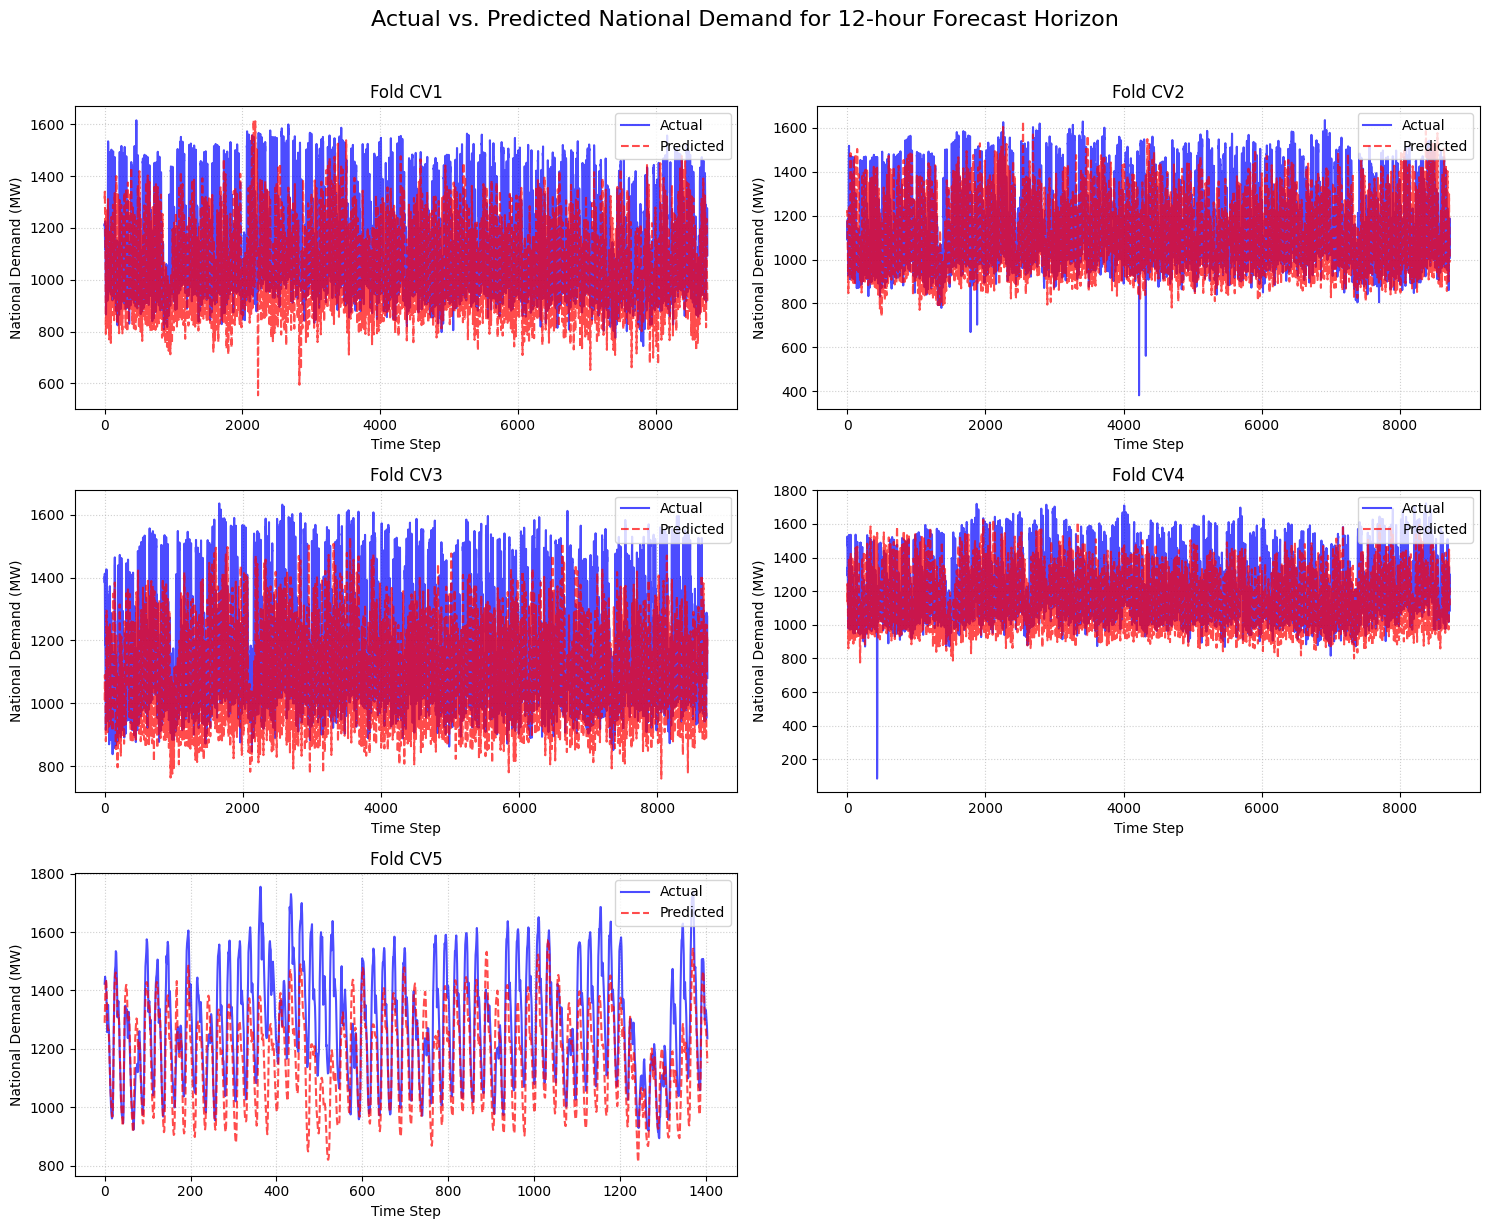



--- Visualization for Horizon: 24 hours ahead ---


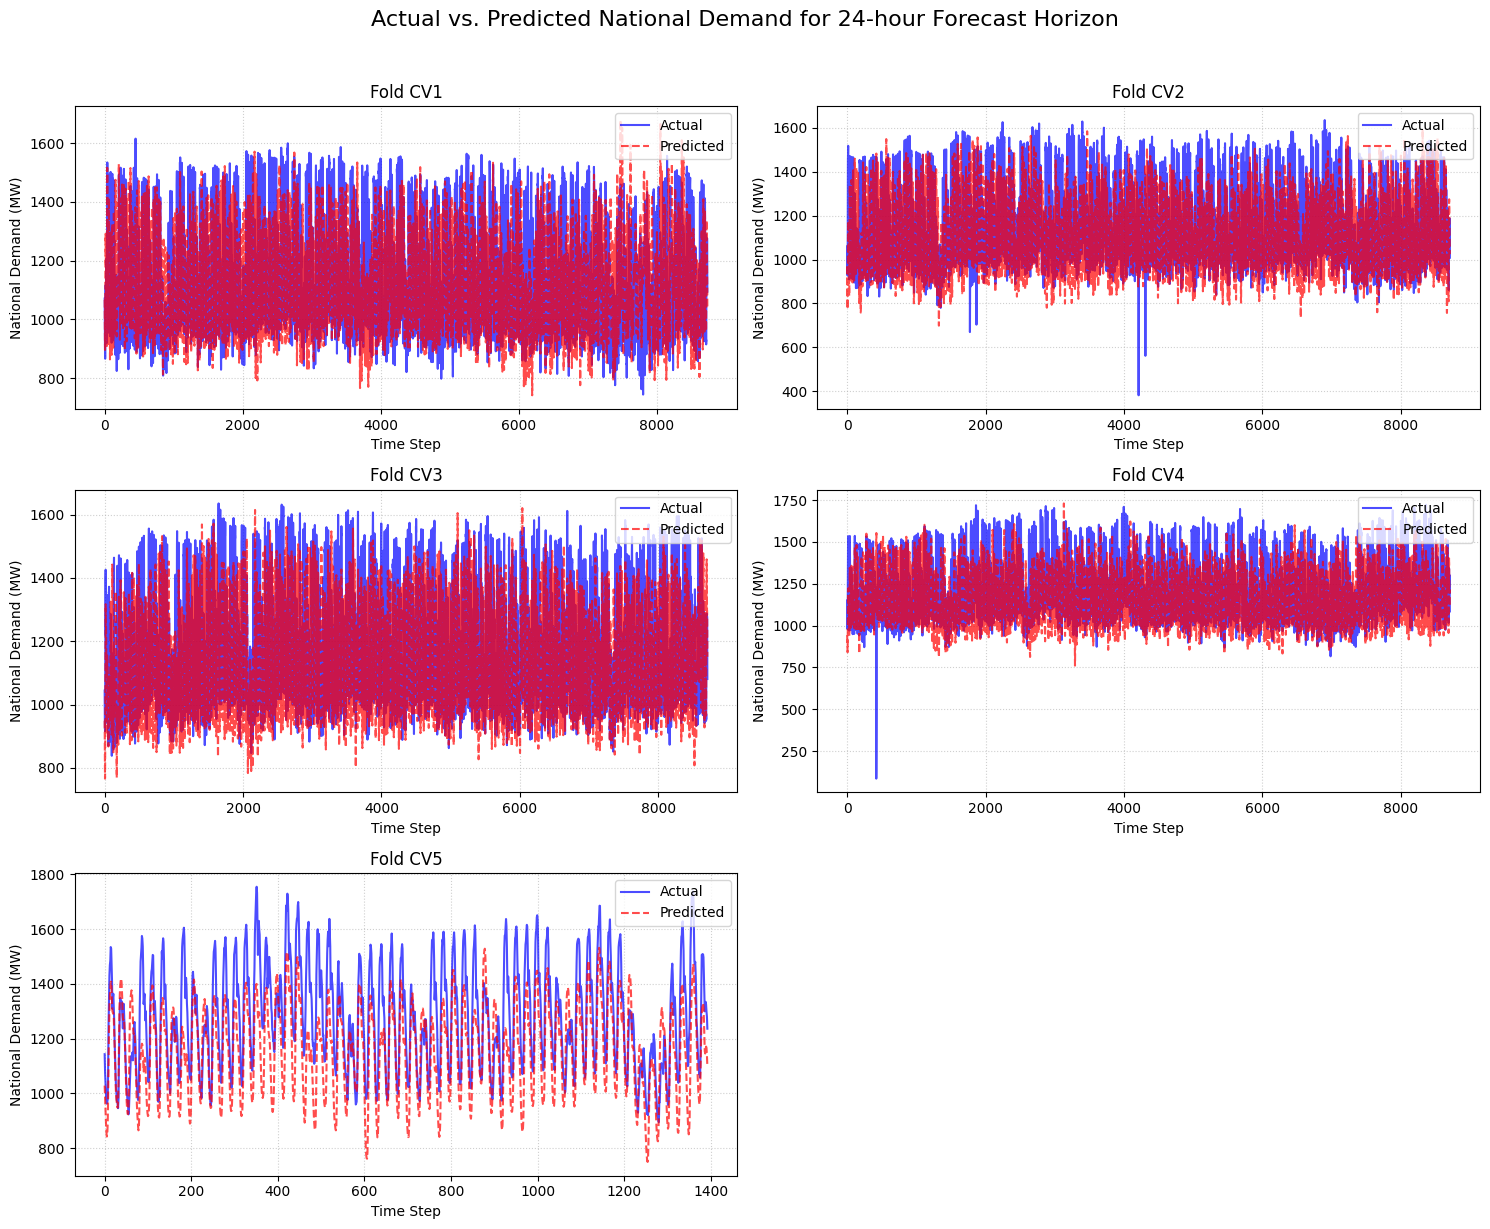



VISUALIZATION COMPLETE


In [21]:
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("VISUALIZING ACTUAL vs. PREDICTED VALIDATION METRICS")
print("="*80 + "\n")

for horizon in horizons:
    print(f"--- Visualization for Horizon: {horizon} hours ahead ---")

    # Determine number of folds dynamically to set up subplot grid
    num_folds = len(results[horizon])

    # Calculate grid dimensions (e.g., 2 rows for 5 folds would be 3x2)
    # Plus one more row for a legend below the plots if needed
    n_cols = 2 # Or 3 if num_folds allows for better aspect ratio
    n_rows = (num_folds + n_cols - 1) // n_cols # Ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), squeeze=False)
    axes = axes.flatten() # Flatten for easy iteration

    for i, fold_name in enumerate(sorted(results[horizon].keys())):
        ax = axes[i]
        data = results[horizon][fold_name]
        y_true = data['y_true'].ravel() # Ensure 1D array
        y_pred = data['y_pred'].ravel() # Ensure 1D array

        ax.plot(y_true, label='Actual', alpha=0.7, color='blue')
        ax.plot(y_pred, label='Predicted', alpha=0.7, color='red', linestyle='--')
        ax.set_title(f'Fold {fold_name.upper()}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('National Demand (MW)')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Actual vs. Predicted National Demand for {horizon}-hour Forecast Horizon', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    print("\n")

print("="*80)
print("VISUALIZATION COMPLETE")
print("="*80)

In [24]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt # Already imported, but good to ensure

# Make sure SHAP is installed
try:
    import shap
except ImportError:
    %pip install shap
    import shap

print("="*80)
print("SHAP ANALYSIS FOR TCN MODEL")
print("="*80 + "\n")

# --- 1. Select a trained model and data for explanation ---
# We'll use the model trained for the first horizon (12h) and the first CV fold (CV1)
selected_horizon = horizons[0] # 12 hours
selected_fold = 'cv1'

print(f"Performing SHAP analysis for Horizon: {selected_horizon}h, Fold: {selected_fold.upper()}\n")

# Retrieve the trained model from the results dictionary
model_to_explain = results[selected_horizon][selected_fold]['model']

# Retrieve the scaled training and validation data for the selected fold
data_for_shap = cv_data_prepared[selected_horizon][selected_fold]

X_train_scaled_np = data_for_shap['X_train_scaled']
X_val_scaled_np = data_for_shap['X_val_scaled']

feature_names = feature_cols_numeric # Defined in C6, assumed global

# Ensure the model is on the correct device and in evaluation mode
model_to_explain.to(device)
model_to_explain.eval()

# --- 2. Prepare background data for DeepExplainer ---
# DeepExplainer needs a background dataset to estimate feature contributions.
# Using a random subset of the training data as background.
# Convert numpy array to torch.Tensor and move to device.
num_background_samples = min(100, X_train_scaled_np.shape[0]) # Use up to 100 samples or all if less
background_indices = np.random.choice(X_train_scaled_np.shape[0], num_background_samples, replace=False)
background_data_tensor = torch.tensor(X_train_scaled_np[background_indices], dtype=torch.float32).to(device)

# --- 3. Prepare data to be explained ---
# Select a few instances from the validation set to explain.
num_explain_instances = min(5, X_val_scaled_np.shape[0]) # Explain up to 5 samples
explain_indices = np.arange(num_explain_instances)
test_instances_tensor = torch.tensor(X_val_scaled_np[explain_indices], dtype=torch.float32).to(device)
test_instances_np = X_val_scaled_np[explain_indices] # Keep numpy version for plotting

# --- 4. Create a SHAP DeepExplainer ---
print("Initializing SHAP DeepExplainer...")
explainer = shap.DeepExplainer(model_to_explain, background_data_tensor)

# --- 5. Calculate SHAP values ---
print(f"Calculating SHAP values for {test_instances_tensor.shape[0]} test instances...")
shap_values = explainer.shap_values(test_instances_tensor)

# Convert SHAP values from tensor to numpy for plotting
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.detach().cpu().numpy()

# The SHAP values for TCN (sequence model) will be (num_instances, lookback, num_features).
# For summary and force plots, it's common to average SHAP values over the lookback window.
shap_values_avg_over_time = np.mean(shap_values, axis=1) # Shape: (num_instances, num_features)

# --- 6. Visualize SHAP results ---
print("\nGenerating SHAP Summary Plot...")
# For the feature values in the summary plot, we can use the average feature values over the lookback window.
test_instances_avg_over_time = np.mean(test_instances_np, axis=1) # Shape: (num_instances, num_features)

shap.summary_plot(shap_values_avg_over_time, test_instances_avg_over_time, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary Plot (Horizon: {selected_horizon}h, Fold: {selected_fold.upper()})")
plt.tight_layout()
plt.show()

# Generating SHAP waterfall plot for the first explained instance
if num_explain_instances > 0:
    print("\nGenerating SHAP Waterfall Plot for the first explained instance...")
    instance_to_explain_idx = 0
    single_instance_shap_values = shap_values_avg_over_time[instance_to_explain_idx] # (num_features,)
    single_instance_features = test_instances_avg_over_time[instance_to_explain_idx] # (num_features,)

    # The `expected_value` for DeepExplainer comes from the explainer object.
    # It might be a single value or a list if the model has multiple outputs.
    expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value
    # Convert expected_value to numpy if it's a tensor
    if isinstance(expected_value, torch.Tensor):
        expected_value = expected_value.detach().cpu().numpy()

    shap.waterfall_plot(shap.Explanation(values=single_instance_shap_values,
                                        base_values=expected_value,
                                        data=single_instance_features,
                                        feature_names=feature_names),
                       show=False)
    plt.title(f"SHAP Waterfall Plot (Instance {instance_to_explain_idx}, Horizon: {selected_horizon}h, Fold: {selected_fold.upper()})")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough instances to generate waterfall plot.")


print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE")
print("="*80)


SHAP ANALYSIS FOR TCN MODEL

Performing SHAP analysis for Horizon: 12h, Fold: CV1



KeyError: 'cv1'